# Three-method cutoff-power-law SED comparison

This notebook compares three SED constructions for cutoff power laws with fixed index $-2$ and cutoff energies 200, 1000, and 5000 keV: simultaneous `BinnedSED`, simultaneous frozen-global-cutoff bins, and point-source Richardson-Lucy spectral deconvolution.

Every source is generated directly with `SourceInjector.inject_point_source` and added to the same DC4 background used in the two-method comparison notebook. The orientation is restricted in memory to times when the source is within 60 degrees of the pointing direction, matching the background product's FOV selection. The two simultaneous likelihood methods use identical 3ML/Minuit multi-start normalizations. Richardson-Lucy follows `NGC4151-RL-Spectral-Deconvolution.ipynb`: it unfolds integrated incident-energy-bin fluxes for 1000 ML-EM iterations with the background fixed at one, then divides by bin width. It has no vertical error bars; a conditional Poisson TS and 95% upper limit are evaluated afterward with all other RL bands fixed, using the same $TS<1$ reporting threshold.

## 1. Imports and three-case configuration

In [1]:
from pathlib import Path
from functools import lru_cache
import shutil
import tempfile

import cosipy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astromodels import Cutoff_powerlaw, Model, Parameter, PointSource
from histpy import Histogram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import brentq, minimize, minimize_scalar
from threeML import DataList, JointLikelihood, PluginPrototype

from cosipy import BinnedData
from cosipy.data_io import EmCDSBinnedData
from cosipy.image_deconvolution import select_orientation_for_pointing_cut
from cosipy.response import BinnedInstrumentResponse, PointSourceResponse
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.functions import get_integrated_spectral_model
from cosipy.source_injector import SourceInjector
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml import BinnedSED


# Consistent DC4 orientation, response, and background products.
DC4_DATA_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)

AGN_ORIENTATION_CANDIDATES = [
    DC4_DATA_DIR / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits",
]
AGN_RESPONSE_CANDIDATES = [
    DC4_DATA_DIR / (
        "ResponseContinuum.o3.e100_10000.b10log."
        "s10396905069491.m2284.filtered.nonsparse.binnedimaging."
        "imagingresponse.h5"
    ),
]
AGN_BACKGROUND_CANDIDATES = [
    DC4_DATA_DIR / (
        "Background/Total_DC4_BG_3months_binned_data_filtered_"
        "with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5"
    ),
]
AGN_YAML_NAMES = (
    "background.yaml",
    "NGC4151_ec200.yaml",
    "NGC4151_ec1000.yaml",
)
AGN_YAML_SEARCH_DIRS = (
    Path("."),
    Path("docs/tutorials/spectral_fits/sed_model"),
    Path(cosipy.__file__).resolve().parents[1]
    / "docs/tutorials/spectral_fits/sed_model",
)

CUTOFF_ENERGIES_KEV = (200.0, 1000.0, 5000.0)
INJECTED_INDEX = -2.0
LOCAL_SED_INDEX = -2.0
CUTOFF_FIT_BOUNDS_KEV = (100.0, 50000.0)
INITIAL_BIN_FLUX = 1.0e-7  # reference differential flux at each bin pivot
MINUIT_START_FLUXES = (1.0e-9, 1.0e-8, 1.0e-7, 1.0e-6, 1.0e-5)
RL_ITERATIONS = 1000
RL_INITIAL_BAND_FLUX = 1.0e-4  # integrated flux per Ei bin
TS_THRESHOLD = 1.0
INTEGRATED_PHOTON_FLUX = 3.0e-4
CUTOFF_PIVOT_KEV = 200.0
SOURCE_LONGITUDE_DEG = 155.07
SOURCE_LATITUDE_DEG = 75.06
FOV_CUT = 60 * u.deg
PHOTON_FLUX_DENSITY_UNIT = 1.0 / (u.keV * u.cm**2 * u.s)


12:20:43 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=435555;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=359742;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=61939;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=700269;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

12:20:44 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=387169;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=393976;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

12:20:44 INFO      Starting 3ML!                                                                     ]8;id=436022;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=14041;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=807230;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=680929;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=661249;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=88489;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

12:20:45 WARNING   No fermitools installed                                              ]8;id=401548;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=619929;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=650169;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=551262;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=211545;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=302785;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=900487;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=356028;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## 2. DC4 input and spectral helpers

In [2]:
def _first_existing_path(candidates, label):
    for path in candidates:
        if path.exists():
            return path
    attempted = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find the {label}. Tried:\n{attempted}")


def _resolve_agn_yamls():
    return {
        name: _first_existing_path(
            [directory / name for directory in AGN_YAML_SEARCH_DIRS],
            f"copied AGN YAML {name}",
        )
        for name in AGN_YAML_NAMES
    }


def _dense_values(histogram):
    values = histogram.contents
    if hasattr(values, "todense"):
        values = values.todense()
    if isinstance(values, u.Quantity):
        values = values.value
    return np.asarray(values, dtype=float)


def _open_agn_orientation(path):
    """Open the branch .ori file, tolerating its missing final EN marker."""
    try:
        return SpacecraftHistory.open(path)
    except ValueError as error:
        if "must end with final line 'EN'" not in str(error):
            raise
        with tempfile.NamedTemporaryFile(suffix=".ori") as repaired:
            with path.open("rb") as original:
                shutil.copyfileobj(original, repaired)
            repaired.write(b"EN\n")
            repaired.flush()
            return SpacecraftHistory.open(repaired.name)


def _open_compatible_response(candidates):
    """Prefer the branch response, skipping legacy formats this reader rejects."""
    failures = []
    for path in candidates:
        if not path.exists():
            continue
        try:
            return path, FullDetectorResponse.open(path)
        except RuntimeError as error:
            if "Response format is version" not in str(error):
                raise
            failures.append(f"{path}: {error}")
    detail = "\n".join(failures) or "no candidate files exist"
    raise RuntimeError(f"No compatible AGN response was found:\n{detail}")


def _axis_edges_keV(axis):
    edges = axis.edges
    if isinstance(edges, u.Quantity):
        return np.asarray(edges.to_value(u.keV), dtype=float)
    return np.asarray(edges, dtype=float)


def _cutoff_integral_coefficient(index, cutoff_keV, pivot, elo, ehi):
    """Integral for K=1 of (E/pivot)^index exp(-E/cutoff)."""
    if not np.isfinite(cutoff_keV) or cutoff_keV <= 0.0:
        raise ValueError("cutoff_keV must be finite and positive.")
    value, _ = quad(
        lambda energy: (
            (energy / pivot) ** index * np.exp(-energy / cutoff_keV)
        ),
        elo,
        ehi,
        epsabs=0.0,
        epsrel=1.0e-10,
    )
    return float(value)


def _make_cutoff_powerlaw(
    cutoff_keV,
    normalization,
    index=INJECTED_INDEX,
    pivot=CUTOFF_PIVOT_KEV,
):
    spectrum = Cutoff_powerlaw()
    spectrum.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
    spectrum.K.value = float(normalization)
    spectrum.piv.value = float(pivot)
    spectrum.index.value = float(index)
    spectrum.xc.value = float(cutoff_keV)
    return spectrum


## 3. Likelihood and Minuit helpers

The two forward-folded methods use the same Poisson likelihood, five data-independent starting normalizations, and one final Minuit refinement. Their existing background definitions are preserved.

In [3]:

def _poisson_nll(data, model):
    """Poisson deviance / 2, with the saturated-model constant removed."""
    model = np.clip(np.asarray(model, dtype=float), np.finfo(float).tiny, None)
    data = np.asarray(data, dtype=float)
    positive = data > 0.0
    value = np.sum(model[~positive])
    value += np.sum(
        model[positive]
        - data[positive]
        + data[positive] * np.log(data[positive] / model[positive])
    )
    return float(value)


def _fit_positive_components(data, components, start=None, fixed_model=None):
    """Fit non-negative amplitudes multiplying fixed detector-space templates."""
    data = np.asarray(data, dtype=float).ravel()
    components = np.asarray(components, dtype=float).reshape(len(components), -1)
    if fixed_model is None:
        fixed_model = np.zeros_like(data)
    else:
        fixed_model = np.asarray(fixed_model, dtype=float).ravel()

    if start is None:
        start = np.ones(components.shape[0])
    start = np.clip(np.asarray(start, dtype=float), 1.0e-30, None)

    # Parameterize each coefficient by its expected component counts. This
    # removes the enormous column-scale differences produced by steep cutoffs.
    component_sums = np.sum(components, axis=1)
    if np.any(~np.isfinite(component_sums)) or np.any(component_sums <= 0.0):
        raise ValueError("Every fitted component must have a positive finite sum.")
    normalized_components = components / component_sums[:, None]
    expected_counts = start * component_sums
    tiny = np.finfo(float).tiny

    # Multiplicative Poisson updates provide a robust warm start while retaining
    # the exact physical starting amplitudes supplied above.
    for _ in range(100):
        raw_model = fixed_model + expected_counts @ normalized_components
        model = np.clip(raw_model, tiny, None)
        ratio = np.zeros_like(data)
        supported = (raw_model > tiny) & (data > 0.0)
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            ratio[supported] = data[supported] / model[supported]
        ratio = np.nan_to_num(ratio, nan=0.0, posinf=1.0e100, neginf=0.0)
        updated_counts = expected_counts * (normalized_components @ ratio)
        updated_counts = np.nan_to_num(
            updated_counts, nan=0.0, posinf=1.0e100, neginf=0.0
        )
        relative_change = np.max(
            np.abs(updated_counts - expected_counts) / (1.0 + expected_counts)
        )
        expected_counts = updated_counts
        if relative_change < 1.0e-8:
            break

    variable_scales = np.maximum(expected_counts, 1.0)
    scaled_components = variable_scales[:, None] * normalized_components

    def objective(relative_counts):
        raw_model = fixed_model + relative_counts @ scaled_components
        model = np.clip(raw_model, tiny, None)
        nll = _poisson_nll(data, model)
        score = np.zeros_like(model)
        supported = raw_model > tiny
        score[supported] = 1.0 - data[supported] / model[supported]
        gradient = scaled_components @ score
        return nll, gradient

    bounds = [(0.0, None)] * components.shape[0]
    result = minimize(
        objective,
        x0=expected_counts / variable_scales,
        method="L-BFGS-B",
        jac=True,
        bounds=bounds,
        options={
            "ftol": 1.0e-13,
            "gtol": 1.0e-9,
            "maxiter": 8000,
            "maxls": 100,
        },
    )
    if not result.success:
        result = minimize(
            objective,
            x0=np.clip(result.x, 0.0, None),
            method="SLSQP",
            jac=True,
            bounds=bounds,
            options={"ftol": 1.0e-11, "maxiter": 8000},
        )
    if not result.success:
        raise RuntimeError(f"Component fit failed: {result.message}")

    amplitudes = variable_scales * result.x / component_sums
    model = fixed_model + amplitudes @ components
    return amplitudes, _poisson_nll(data, model)


class _TemplatePoissonPlugin(PluginPrototype):
    """3ML plugin for non-negative amplitudes of folded detector templates."""

    def __init__(
        self,
        name,
        data,
        templates,
        background,
        spectrum,
        reference_flux,
        background_start,
        background_free,
    ):
        self._data = np.asarray(data, dtype=float).ravel()
        self._templates = np.asarray(templates, dtype=float).reshape(
            len(templates), -1
        )
        self._background = np.asarray(background, dtype=float).ravel()
        self._normalizations = tuple(spectrum.normalizations)
        self._reference_flux = float(reference_flux)
        if self._templates.shape[0] != len(self._normalizations):
            raise ValueError("Each Minuit normalization needs one template.")
        if self._templates.shape[1] != self._data.size:
            raise ValueError("Template and data shapes do not match.")
        if self._background.size != self._data.size:
            raise ValueError("Background and data shapes do not match.")

        background_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            background_name,
            float(background_start),
            min_value=0.0,
            max_value=10.0,
            delta=0.05,
            free=bool(background_free),
        )
        super().__init__(name, {background_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        amplitudes = np.asarray(
            [parameter.value for parameter in self._normalizations], dtype=float
        ) / self._reference_flux
        model = (
            amplitudes @ self._templates
            + float(self.background_scale.value) * self._background
        )
        return -_poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def _minuit_status(like):
    """Return the Minuit convergence fields used to rank multi-start fits."""
    fmin = like.minimizer.minuit.fmin
    return {
        "valid": bool(getattr(fmin, "is_valid", False)),
        "edm": float(getattr(fmin, "edm", np.nan)),
        "call_limit": bool(getattr(fmin, "has_reached_call_limit", False)),
        "above_max_edm": bool(getattr(fmin, "is_above_max_edm", False)),
        "at_limit": bool(getattr(fmin, "has_parameters_at_limit", False)),
    }


def _fit_templates_with_minuit(
    data,
    templates,
    background,
    detector_response,
    ei_bin_indices,
    reference_flux,
    local_index,
    start_fluxes,
    background_start,
    background_free,
    fit_tag,
):
    """Fit template amplitudes with 3ML/Minuit from several fixed starts."""
    starts = tuple(float(value) for value in start_fluxes)
    if not starts or any((not np.isfinite(value) or value <= 0.0) for value in starts):
        raise ValueError("Minuit starting fluxes must be finite and positive.")

    bins = tuple(int(index) for index in ei_bin_indices)
    spectrum = BinnedSED.from_response(
        detector_response,
        ei_bin_indices=bins,
        initial_fluxes=[starts[0]] * len(bins),
        index=local_index,
    )
    for parameter in spectrum.normalizations:
        parameter.min_value = 0.0
        parameter.max_value = 1.0e-2
        parameter.delta = max(0.2 * starts[0], 1.0e-12)
        parameter.free = True

    source = PointSource(
        f"source_{fit_tag}",
        l=SOURCE_LONGITUDE_DEG,
        b=SOURCE_LATITUDE_DEG,
        spectral_shape=spectrum,
    )
    model = Model(source)
    plugin = _TemplatePoissonPlugin(
        f"plugin_{fit_tag}",
        data,
        templates,
        background,
        spectrum,
        reference_flux,
        background_start,
        background_free,
    )
    like = JointLikelihood(
        model, DataList(plugin), verbose=False, record=False
    )
    like.set_minimizer("minuit")

    trial_rows = []
    candidates = []
    for start_flux in starts:
        for parameter in spectrum.normalizations:
            parameter.value = start_flux
            parameter.delta = max(0.2 * start_flux, 1.0e-12)
            parameter.free = True
        plugin.background_scale.value = float(background_start)
        plugin.background_scale.free = bool(background_free)

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = _minuit_status(like)
            nll = float(like.current_minimum)
            values = np.asarray(
                [parameter.value for parameter in spectrum.normalizations],
                dtype=float,
            )
            background_value = float(plugin.background_scale.value)
            error = ""
        except Exception as exc:
            status = {
                "valid": False,
                "edm": np.nan,
                "call_limit": False,
                "above_max_edm": False,
                "at_limit": False,
            }
            nll = np.inf
            values = None
            background_value = np.nan
            error = f"{type(exc).__name__}: {exc}"

        trial_rows.append(
            {
                "fit_tag": fit_tag,
                "stage": "multi-start",
                "start_flux": start_flux,
                "nll": nll,
                "background_scale": background_value,
                "error": error,
                **status,
            }
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append((nll, values.copy(), background_value))

    if not candidates:
        diagnostics = pd.DataFrame(trial_rows)
        raise RuntimeError(
            f"No valid Minuit solution for {fit_tag}.\n{diagnostics.to_string(index=False)}"
        )

    best_nll, best_values, best_background = min(candidates, key=lambda item: item[0])
    for parameter, value in zip(spectrum.normalizations, best_values):
        parameter.value = float(value)
        parameter.delta = max(0.2 * max(float(value), starts[0]), 1.0e-12)
    plugin.background_scale.value = best_background

    # One final MIGRAD pass starts from the best valid multi-start solution.
    try:
        like.fit(quiet=True, compute_covariance=False)
        refine_status = _minuit_status(like)
        refine_nll = float(like.current_minimum)
        refine_values = np.asarray(
            [parameter.value for parameter in spectrum.normalizations], dtype=float
        )
        refine_background = float(plugin.background_scale.value)
        refine_error = ""
    except Exception as exc:
        refine_status = {
            "valid": False,
            "edm": np.nan,
            "call_limit": False,
            "above_max_edm": False,
            "at_limit": False,
        }
        refine_nll = np.inf
        refine_values = None
        refine_background = np.nan
        refine_error = f"{type(exc).__name__}: {exc}"

    trial_rows.append(
        {
            "fit_tag": fit_tag,
            "stage": "refine",
            "start_flux": np.nan,
            "nll": refine_nll,
            "background_scale": refine_background,
            "error": refine_error,
            **refine_status,
        }
    )
    if refine_status["valid"] and refine_nll <= best_nll:
        best_nll = refine_nll
        best_values = refine_values.copy()
        best_background = refine_background

    for parameter, value in zip(spectrum.normalizations, best_values):
        parameter.value = float(value)
    plugin.background_scale.value = float(best_background)

    objectives = []
    for parameter in spectrum.normalizations:
        def objective(scale, parameter=parameter):
            saved_value = float(parameter.value)
            try:
                parameter.value = max(float(scale), 0.0) * reference_flux
                return -float(plugin.get_log_like())
            finally:
                parameter.value = saved_value

        objectives.append(objective)

    return {
        "amplitudes": best_values / reference_flux,
        "nll": float(best_nll),
        "background_scale": float(best_background),
        "objectives": tuple(objectives),
        "trials": pd.DataFrame(trial_rows),
        "like": like,
        "plugin": plugin,
        "spectrum": spectrum,
    }


def _profile_root(objective, best, nll_best, delta_nll, direction):
    def crossing(value):
        return objective(value) - nll_best - delta_nll

    if direction < 0:
        if best <= 0.0 or crossing(0.0) < 0.0:
            return 0.0
        return float(brentq(crossing, 0.0, best))

    upper = max(2.0 * best, best + 1.0, 1.0)
    for _ in range(60):
        if crossing(upper) >= 0.0:
            return float(brentq(crossing, best, upper))
        upper *= 2.0
    return np.nan


def _conditional_summary(best, nll_best, objective):
    """TS, conditional 68% interval, and one-sided 95% UL for one amplitude."""
    ts = max(0.0, 2.0 * (objective(0.0) - nll_best))
    low = _profile_root(objective, best, nll_best, 0.5, -1)
    high = _profile_root(objective, best, nll_best, 0.5, +1)
    ul95 = _profile_root(objective, best, nll_best, 1.355, +1)
    return ts, low, high, ul95


## 4. Point-source Richardson-Lucy helper

This is the spectral ML-EM update from the referenced deconvolution notebook, applied to the injected Asimov data rather than a precomputed NGC 4151 source file. The DC4 background remains fixed at its known normalization.

In [4]:
def _run_point_source_rl(
    data,
    background,
    point_response,
    energy_edges_keV,
    iterations=RL_ITERATIONS,
    initial_band_flux=RL_INITIAL_BAND_FLUX,
):
    """Run the point-source spectral ML-EM/Richardson-Lucy update."""
    data_counts = np.asarray(data, dtype=float).reshape(-1)
    background_model = np.asarray(background, dtype=float).reshape(-1)
    response_matrix = np.asarray(
        point_response.contents.value, dtype=float
    ).reshape(len(energy_edges_keV) - 1, -1)
    if response_matrix.shape[1] != data_counts.size:
        raise ValueError("Point response and data shapes do not match.")

    summed_response = response_matrix.sum(axis=1)
    if np.any(~np.isfinite(summed_response)) or np.any(summed_response <= 0.0):
        raise ValueError("Every incident-energy bin needs positive exposure.")
    if iterations <= 0 or initial_band_flux <= 0.0:
        raise ValueError("RL iterations and initial band flux must be positive.")

    band_flux = np.full(response_matrix.shape[0], float(initial_band_flux))
    nll_trace = []
    for _ in range(int(iterations)):
        expectation = background_model + band_flux @ response_matrix
        data_ratio = np.divide(
            data_counts,
            expectation,
            out=np.zeros_like(data_counts),
            where=expectation > 0.0,
        )
        band_flux *= (response_matrix @ data_ratio) / summed_response
        expectation = background_model + band_flux @ response_matrix
        nll_trace.append(_poisson_nll(data_counts, expectation))

    final_expectation = background_model + band_flux @ response_matrix
    best_nll = _poisson_nll(data_counts, final_expectation)
    ts_values = np.empty_like(band_flux)
    ul95_band_flux = np.empty_like(band_flux)
    for bin_index, best_band_flux in enumerate(band_flux):
        fixed_model = (
            final_expectation
            - best_band_flux * response_matrix[bin_index]
        )

        def objective(value, fixed=fixed_model, template=response_matrix[bin_index]):
            return _poisson_nll(
                data_counts, fixed + max(float(value), 0.0) * template
            )

        conditional_nll = objective(best_band_flux)
        ts_values[bin_index] = max(
            0.0, 2.0 * (objective(0.0) - conditional_nll)
        )
        ul95_band_flux[bin_index] = _profile_root(
            objective, best_band_flux, conditional_nll, 1.355, +1
        )

    energy_widths = np.diff(np.asarray(energy_edges_keV, dtype=float))
    return {
        "band_flux": band_flux,
        "flux": band_flux / energy_widths,
        "nll": float(best_nll),
        "nll_trace": np.asarray(nll_trace),
        "TS": ts_values,
        "ul95": ul95_band_flux / energy_widths,
        "iterations": int(iterations),
        "background_scale": 1.0,
    }


## 5. Generate the data and run all three methods

In [5]:
def compare_three_cutoff_sed_methods(
    cutoff_energies_keV=CUTOFF_ENERGIES_KEV,
    fixed_index=INJECTED_INDEX,
    integrated_photon_flux=INTEGRATED_PHOTON_FLUX,
    local_sed_index=LOCAL_SED_INDEX,
    initial_bin_flux=INITIAL_BIN_FLUX,
    minuit_start_fluxes=MINUIT_START_FLUXES,
    ts_threshold=TS_THRESHOLD,
    cutoff_fit_bounds_keV=CUTOFF_FIT_BOUNDS_KEV,
    rl_iterations=RL_ITERATIONS,
    rl_initial_band_flux=RL_INITIAL_BAND_FLUX,
):
    """
    Compare BinnedSED, frozen-cutoff, and Richardson-Lucy SED points.

    The injected and globally fitted photon index is fixed. The global fit
    floats cutoff energy, source normalization, and background scale. The
    frozen methods retain that fitted cutoff shape inside each energy bin.
    Both simultaneous per-bin fits use the same 3ML/Minuit multi-start grid,
    independent of the data and injected normalization.
    """
    orientation_path = _first_existing_path(
        AGN_ORIENTATION_CANDIDATES, "AGN orientation file"
    )
    response_path, detector_response = _open_compatible_response(
        AGN_RESPONSE_CANDIDATES
    )
    background_path = _first_existing_path(
        AGN_BACKGROUND_CANDIDATES, "AGN background file"
    )
    yaml_paths = _resolve_agn_yamls()

    agn_configs = {name: BinnedData(path) for name, path in yaml_paths.items()}
    background_data = agn_configs["background.yaml"]
    background_data.load_binned_data_from_hdf5(background_path)
    background_hist = background_data.binned_data.project("Em", "Phi", "PsiChi")
    data_definition = EmCDSBinnedData(background_hist)
    background_counts = _dense_values(background_hist)

    orientation = _open_agn_orientation(orientation_path)
    instrument_response = BinnedInstrumentResponse(
        detector_response, data_definition
    )
    source_coord = SkyCoord(
        l=SOURCE_LONGITUDE_DEG * u.deg,
        b=SOURCE_LATITUDE_DEG * u.deg,
        frame="galactic",
    )
    orientation = select_orientation_for_pointing_cut(
        orientation, source_coord, FOV_CUT
    )
    scatt_map = orientation.get_scatt_map(
        nside=2 * data_definition.axes["PsiChi"].nside,
        target_coord=source_coord,
        earth_occ=True,
    )
    point_response = PointSourceResponse.from_scatt_map(
        source_coord,
        data_definition,
        instrument_response,
        scatt_map,
        detector_response.axes["Ei"],
        detector_response.axes["Pol"]
        if "Pol" in detector_response.axes.labels
        else None,
    )

    ei_edges = _axis_edges_keV(detector_response.axes["Ei"])
    em_edges = _axis_edges_keV(data_definition.axes["Em"])
    if not np.allclose(ei_edges, em_edges):
        raise ValueError(
            "This compact comparison requires matching Ei and Em edges so "
            "the methods can be plotted and differenced bin by bin."
        )
    for yaml_name, config in agn_configs.items():
        if not np.allclose(np.asarray(config.energy_bins, dtype=float), em_edges):
            raise ValueError(f"Energy bins in {yaml_name} do not match the data.")
        if int(180 / config.phi_pix_size) != data_definition.axes["Phi"].nbins:
            raise ValueError(f"Phi bins in {yaml_name} do not match the data.")
        if int(config.nside) != data_definition.axes["PsiChi"].nside:
            raise ValueError(f"PsiChi nside in {yaml_name} does not match the data.")

    energy = np.sqrt(ei_edges[:-1] * ei_edges[1:])
    n_energy_bins = energy.size
    base_k = 1.0e-6
    if not np.isfinite(initial_bin_flux) or initial_bin_flux <= 0.0:
        raise ValueError("initial_bin_flux must be finite and positive.")
    minuit_start_fluxes = tuple(map(float, minuit_start_fluxes))
    if not minuit_start_fluxes or any(
        (not np.isfinite(value) or value <= 0.0)
        for value in minuit_start_fluxes
    ):
        raise ValueError("minuit_start_fluxes must be finite and positive.")
    cutoff_fit_bounds_keV = tuple(map(float, cutoff_fit_bounds_keV))
    if (
        len(cutoff_fit_bounds_keV) != 2
        or cutoff_fit_bounds_keV[0] <= 0.0
        or cutoff_fit_bounds_keV[1] <= cutoff_fit_bounds_keV[0]
    ):
        raise ValueError("cutoff_fit_bounds_keV must be positive and increasing.")

    injector = SourceInjector(response_path=response_path)

    @lru_cache(maxsize=None)
    def folded_cutoff(cutoff_keV):
        model = _make_cutoff_powerlaw(cutoff_keV, base_k, fixed_index)
        return _dense_values(point_response.get_expectation(model))

    @lru_cache(maxsize=None)
    def folded_cutoff_bins(cutoff_keV):
        """Per-bin cutoff templates normalized to base_k at each pivot."""
        model = _make_cutoff_powerlaw(cutoff_keV, base_k, fixed_index)
        integrated_flux = get_integrated_spectral_model(
            model, point_response.photon_energy_axis
        )
        integrated_values = _dense_values(integrated_flux)
        shape_at_energy = (
            (energy / CUTOFF_PIVOT_KEV) ** fixed_index
            * np.exp(-energy / cutoff_keV)
        )
        templates = []
        for bin_index in range(n_energy_bins):
            masked_values = np.zeros_like(integrated_values)
            masked_values[bin_index] = (
                integrated_values[bin_index] / shape_at_energy[bin_index]
            )
            masked_flux = Histogram(
                integrated_flux.axes,
                contents=masked_values,
                unit=integrated_flux.unit,
                copy_contents=False,
            )
            templates.append(
                _dense_values(
                    point_response.get_expectation(model, flux=masked_flux)
                )
            )
        return np.asarray(templates)

    # Unit-amplitude templates for simultaneous BinnedSED.
    sed_templates = []
    for bin_index in range(n_energy_bins):
        local_model = BinnedSED.from_response(
            detector_response,
            ei_bin_indices=[bin_index],
            initial_fluxes=[base_k],
            index=local_sed_index,
        )
        local_model.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
        sed_templates.append(
            _dense_values(point_response.get_expectation(local_model))
        )
    sed_templates = np.asarray(sed_templates)

    rows = []
    global_rows = []
    minuit_trial_tables = []

    for injected_cutoff_keV in map(float, cutoff_energies_keV):
        band_coefficient = _cutoff_integral_coefficient(
            fixed_index,
            injected_cutoff_keV,
            CUTOFF_PIVOT_KEV,
            ei_edges[0],
            ei_edges[-1],
        )
        injected_k = float(integrated_photon_flux / band_coefficient)
        injected_spectrum = _make_cutoff_powerlaw(
            injected_cutoff_keV, injected_k, fixed_index
        )
        cutoff_tag = f"{injected_cutoff_keV:g}".replace(".", "p")
        injected_hist = injector.inject_point_source(
            spectrum=injected_spectrum,
            coordinate=source_coord,
            orientation=orientation,
            source_name=f"cutoff_powerlaw_ec_{cutoff_tag}keV",
            project_axes=["Em", "Phi", "PsiChi"],
            earth_occ=True,
        )
        injected_signal = _dense_values(injected_hist)
        if injected_signal.shape != background_counts.shape:
            raise ValueError(
                f"Injected/source shape {injected_signal.shape} does not match "
                f"background shape {background_counts.shape}."
            )
        asimov_counts = background_counts + injected_signal

        # Global fit: fixed index; free cutoff, normalization, and background.
        def fit_at_log_cutoff(trial_log10_cutoff):
            trial_cutoff = float(10.0 ** trial_log10_cutoff)
            trial_shape = folded_cutoff(trial_cutoff)
            amplitudes, nll = _fit_positive_components(
                asimov_counts,
                np.stack([trial_shape, background_counts]),
                start=[initial_bin_flux / base_k, 1.0],
            )
            return nll, amplitudes

        log_bounds = np.log10(cutoff_fit_bounds_keV)
        cutoff_fit = minimize_scalar(
            lambda value: fit_at_log_cutoff(value)[0],
            bounds=tuple(log_bounds),
            method="bounded",
            options={"xatol": 1.0e-4},
        )
        if not cutoff_fit.success:
            raise RuntimeError(
                f"Global cutoff-power-law fit failed: {cutoff_fit.message}"
            )

        fitted_cutoff_keV = float(10.0 ** cutoff_fit.x)
        global_nll, global_amplitudes = fit_at_log_cutoff(cutoff_fit.x)
        fitted_k = float(global_amplitudes[0] * base_k)
        fitted_background_scale = float(global_amplitudes[1])
        fitted_global_template = folded_cutoff(fitted_cutoff_keV)
        fitted_shape_at_energy = (
            (energy / CUTOFF_PIVOT_KEV) ** fixed_index
            * np.exp(-energy / fitted_cutoff_keV)
        )

        global_rows.append(
            {
                "injected_cutoff_keV": injected_cutoff_keV,
                "injected_index": float(fixed_index),
                "injected_K": injected_k,
                "fitted_cutoff_keV": fitted_cutoff_keV,
                "fitted_index": float(fixed_index),
                "fitted_K": fitted_k,
                "background_scale": fitted_background_scale,
                "nll": global_nll,
            }
        )

        # Method 1: all BinnedSED normalizations and one background scale.
        binned_fit = _fit_templates_with_minuit(
            data=asimov_counts,
            templates=sed_templates,
            background=background_counts,
            detector_response=detector_response,
            ei_bin_indices=range(n_energy_bins),
            reference_flux=base_k,
            local_index=local_sed_index,
            start_fluxes=minuit_start_fluxes,
            background_start=1.0,
            background_free=True,
            fit_tag=f"binned_ec_{cutoff_tag}",
        )
        minuit_trial_tables.append(
            binned_fit["trials"].assign(
                injected_cutoff_keV=injected_cutoff_keV,
                method="simultaneous BinnedSED",
            )
        )

        for bin_index in range(n_energy_bins):
            best_scale = float(binned_fit["amplitudes"][bin_index])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                binned_fit["nll"],
                binned_fit["objectives"][bin_index],
            )
            rows.append(
                {
                    "injected_cutoff_keV": injected_cutoff_keV,
                    "method": "simultaneous BinnedSED",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": binned_fit["background_scale"],
                }
            )

        # Method 2: simultaneous true-energy bins with fitted cutoff shape.
        frozen_sed_templates = folded_cutoff_bins(fitted_cutoff_keV)
        frozen_sim_fit = _fit_templates_with_minuit(
            data=asimov_counts,
            templates=frozen_sed_templates,
            background=background_counts,
            detector_response=detector_response,
            ei_bin_indices=range(n_energy_bins),
            reference_flux=base_k,
            local_index=local_sed_index,
            start_fluxes=minuit_start_fluxes,
            background_start=fitted_background_scale,
            background_free=False,
            fit_tag=f"frozen_sim_ec_{cutoff_tag}",
        )
        minuit_trial_tables.append(
            frozen_sim_fit["trials"].assign(
                injected_cutoff_keV=injected_cutoff_keV,
                method="simultaneous frozen global shape",
            )
        )

        for bin_index in range(n_energy_bins):
            best_scale = float(frozen_sim_fit["amplitudes"][bin_index])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                frozen_sim_fit["nll"],
                frozen_sim_fit["objectives"][bin_index],
            )
            rows.append(
                {
                    "injected_cutoff_keV": injected_cutoff_keV,
                    "method": "simultaneous frozen global shape",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": fitted_background_scale,
                }
            )

        # Method 3: point-source spectral Richardson-Lucy/ML-EM unfolding.
        # The DC4 background is fixed at normalization one. Returned fluxes
        # are integrated incident-energy-bin fluxes divided by bin width.
        rl_fit = _run_point_source_rl(
            data=asimov_counts,
            background=background_counts,
            point_response=point_response,
            energy_edges_keV=ei_edges,
            iterations=rl_iterations,
            initial_band_flux=rl_initial_band_flux,
        )
        for bin_index in range(n_energy_bins):
            rows.append(
                {
                    "injected_cutoff_keV": injected_cutoff_keV,
                    "method": "Richardson-Lucy",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": float(rl_fit["flux"][bin_index]),
                    "flux_low": np.nan,
                    "flux_high": np.nan,
                    "ul95": float(rl_fit["ul95"][bin_index]),
                    "TS": float(rl_fit["TS"][bin_index]),
                    "is_ul": bool(
                        rl_fit["TS"][bin_index] < ts_threshold
                    ),
                    "background_scale": rl_fit["background_scale"],
                    "rl_iterations": rl_fit["iterations"],
                    "rl_nll": rl_fit["nll"],
                }
            )

    run_info = {
        "orientation": orientation_path,
        "fov_cut_deg": float(FOV_CUT.to_value(u.deg)),
        "selected_livetime_s": float(
            orientation.cumulative_livetime().to_value(u.s)
        ),
        "response": response_path,
        "background": background_path,
        "yaml_files": yaml_paths,
        "cutoff_energies_keV": tuple(map(float, cutoff_energies_keV)),
        "fixed_index": float(fixed_index),
        "local_sed_index": float(local_sed_index),
        "ts_threshold": float(ts_threshold),
        "integrated_photon_flux": float(integrated_photon_flux),
        "initial_bin_flux": float(initial_bin_flux),
        "minuit_start_fluxes": minuit_start_fluxes,
        "minuit_trials": pd.concat(minuit_trial_tables, ignore_index=True),
        "cutoff_fit_bounds_keV": cutoff_fit_bounds_keV,
        "energy_edges_keV": ei_edges,
        "rl_iterations": int(rl_iterations),
        "rl_initial_band_flux": float(rl_initial_band_flux),
        "rl_background_scale": 1.0,
    }
    return pd.DataFrame(rows), pd.DataFrame(global_rows), run_info


In [6]:
# Building the 6.6 GB point-source response can take a few minutes.
sed_comparison, global_cutoff_fits, comparison_info = (
    compare_three_cutoff_sed_methods()
)

print("Files used:")
for label in ("orientation", "response", "background"):
    print(f"  {label}: {comparison_info[label]}")
print(
    f"\nOrientation FOV cut: {comparison_info['fov_cut_deg']:.0f} deg; "
    f"selected livetime: {comparison_info['selected_livetime_s']:,.0f} s"
)
print("\nGlobal fits defining the frozen cutoff and background:")
display(global_cutoff_fits)

minuit_trials = comparison_info["minuit_trials"]
multi_start_trials = minuit_trials[minuit_trials["stage"] == "multi-start"]
minuit_convergence_summary = (
    multi_start_trials.groupby(["injected_cutoff_keV", "method"], as_index=False)
    .agg(
        valid_starts=("valid", "sum"),
        attempted_starts=("valid", "size"),
        best_nll=("nll", "min"),
        any_call_limit=("call_limit", "any"),
        any_above_max_edm=("above_max_edm", "any"),
    )
)
print("\n3ML/Minuit convergence:")
display(minuit_convergence_summary)
print(
    f"Richardson-Lucy: {comparison_info['rl_iterations']} iterations, "
    f"fixed background scale = {comparison_info['rl_background_scale']:.1f}"
)


12:21:10 INFO      set the minimizer to minuit                                             ]8;id=291584;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=793416;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

INFO      set the minimizer to MINUIT                                             ]8;id=244975;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=947651;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

12:21:20 INFO      set the minimizer to minuit                                             ]8;id=89623;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=48332;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

INFO      set the minimizer to MINUIT                                             ]8;id=67540;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=463739;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

12:21:53 INFO      set the minimizer to minuit                                             ]8;id=419583;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=65236;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

Files used:
  orientation: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
  response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5
  background: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5

Orientation FOV cut: 60 deg; selected livetime: 980,415 s

Global fits defining the frozen cutoff and background:


,injected_cutoff_keV,injected_index,injected_K,fitted_cutoff_keV,fitted_index,fitted_K,background_scale,nll
0,200.0,-2.0,2.296079e-06,200.001568,-2.0,2.296062e-06,1.0,3.257855e-11
1,1000.0,-2.0,1.037998e-06,1000.021451,-2.0,1.037991e-06,1.0,1.127832e-10
2,5000.0,-2.0,8.217114e-07,5000.011667,-2.0,8.217112e-07,1.0,3.643286e-12



3ML/Minuit convergence:


,injected_cutoff_keV,method,valid_starts,attempted_starts,best_nll,any_call_limit,any_above_max_edm
0,200.0,simultaneous BinnedSED,5,5,3.743875e-06,False,False
1,200.0,simultaneous frozen global shape,5,5,1.614474e-07,False,False
2,1000.0,simultaneous BinnedSED,5,5,7.526163e-07,False,False
3,1000.0,simultaneous frozen global shape,5,5,6.042760e-06,False,False
4,5000.0,simultaneous BinnedSED,5,5,5.593567e-07,False,False
5,5000.0,simultaneous frozen global shape,5,5,3.627744e-07,False,False


Richardson-Lucy: 1000 iterations, fixed background scale = 1.0


## 6. Compact accuracy summary

Likelihood points are compared with differential truth at the bin center. Richardson-Lucy reconstructs integrated incident-bin flux, so its residuals use bin-averaged truth. For all methods, the residual statistic uses bins with $TS\geq1$ only; bins with $TS<1$ are counted and plotted as 95% upper limits. Richardson-Lucy still has no vertical uncertainty interval for detections.

In [7]:
def _cutoff_truth(cutoff_keV, energy_keV):
    row = global_cutoff_fits.loc[
        global_cutoff_fits["injected_cutoff_keV"] == float(cutoff_keV)
    ].iloc[0]
    energy_keV = np.asarray(energy_keV, dtype=float)
    return (
        float(row["injected_K"])
        * (energy_keV / CUTOFF_PIVOT_KEV) ** INJECTED_INDEX
        * np.exp(-energy_keV / float(cutoff_keV))
    )


def _cutoff_band_average(cutoff_keV):
    edges = comparison_info["energy_edges_keV"]
    injected_k = global_cutoff_fits.loc[
        global_cutoff_fits["injected_cutoff_keV"] == float(cutoff_keV),
        "injected_K",
    ].iloc[0]
    return np.asarray([
        float(injected_k)
        * _cutoff_integral_coefficient(
            INJECTED_INDEX, float(cutoff_keV), CUTOFF_PIVOT_KEV, lower, upper
        )
        / (upper - lower)
        for lower, upper in zip(edges[:-1], edges[1:])
    ])


summary_rows = []
for cutoff_keV in CUTOFF_ENERGIES_KEV:
    for method, group in sed_comparison[
        sed_comparison["injected_cutoff_keV"] == cutoff_keV
    ].groupby("method"):
        group = group.sort_values("bin")
        center_truth = _cutoff_truth(
            cutoff_keV, group["energy_keV"].to_numpy()
        )
        truth = (
            _cutoff_band_average(cutoff_keV)
            if method == "Richardson-Lucy" else center_truth
        )
        used = ~group["is_ul"].fillna(False).to_numpy(dtype=bool)
        upper_limits = int(group["is_ul"].fillna(False).sum())
        residual = 100.0 * (group["flux"].to_numpy() - truth) / truth
        summary_rows.append(
            {
                "injected_cutoff_keV": cutoff_keV,
                "method": method,
                "points_in_residual_summary": int(used.sum()),
                "upper_limits": upper_limits,
                "median_absolute_residual_percent": (
                    float(np.median(np.abs(residual[used]))) if used.any() else np.nan
                ),
            }
        )
accuracy_summary = pd.DataFrame(summary_rows)
display(accuracy_summary)

method_labels = {
    "simultaneous BinnedSED": "BinnedSED",
    "simultaneous frozen global shape": "Simultaneous frozen shape",
    "Richardson-Lucy": "RL deconvolution",
}
method_order = list(method_labels.values())
median_residual_table = (
    accuracy_summary.pivot(
        index="injected_cutoff_keV",
        columns="method",
        values="median_absolute_residual_percent",
    )
    .rename(columns=method_labels)
    .reindex(index=CUTOFF_ENERGIES_KEV, columns=method_order)
)
median_residual_table.index = [
    f"cutoff = {value:g} keV"
    for value in median_residual_table.index
]
median_residual_table.index.name = "Injected cutoff"
median_residual_table.columns.name = None
print("Median absolute residual from injected truth [%]; detections only:")
display(median_residual_table.style.format("{:.3f}", na_rep="—"))

upper_limit_table = (
    accuracy_summary.pivot(
        index="injected_cutoff_keV", columns="method", values="upper_limits"
    )
    .rename(columns=method_labels)
    .reindex(index=CUTOFF_ENERGIES_KEV, columns=method_order)
)
upper_limit_table.index = median_residual_table.index
upper_limit_table.index.name = "Injected cutoff"
upper_limit_table.columns.name = None
print("Number of TS < 1 upper limits excluded from the residual table:")
display(upper_limit_table)


,injected_cutoff_keV,method,points_in_residual_summary,upper_limits,median_absolute_residual_percent
0,200.0,Richardson-Lucy,3,7,24.835800
1,200.0,simultaneous BinnedSED,3,7,1.746213
2,200.0,simultaneous frozen global shape,3,7,0.000341
3,1000.0,Richardson-Lucy,3,7,16.501718
4,1000.0,simultaneous BinnedSED,5,5,0.364462
5,1000.0,simultaneous frozen global shape,5,5,0.002707
6,5000.0,Richardson-Lucy,6,4,20.076322
7,5000.0,simultaneous BinnedSED,6,4,0.079492
8,5000.0,simultaneous frozen global shape,6,4,0.000369


Median absolute residual from injected truth [%]; detections only:


,BinnedSED,Simultaneous frozen shape,RL deconvolution
Injected cutoff,,,
cutoff = 200 keV,1.746,0.000,24.836
cutoff = 1000 keV,0.364,0.003,16.502
cutoff = 5000 keV,0.079,0.000,20.076


Number of TS < 1 upper limits excluded from the residual table:


,BinnedSED,Simultaneous frozen shape,RL deconvolution
Injected cutoff,,,
cutoff = 200 keV,7,7,7
cutoff = 1000 keV,5,5,7
cutoff = 5000 keV,4,4,4


## 7. Per-bin values and TS

In [8]:
from IPython.display import Markdown

for cutoff_keV in CUTOFF_ENERGIES_KEV:
    display(Markdown(f"#### Injected cutoff {cutoff_keV:g} keV"))
    table = sed_comparison[
        sed_comparison["injected_cutoff_keV"] == cutoff_keV
    ][["method", "bin", "energy_keV", "flux", "TS", "is_ul", "ul95"]]
    display(table.reset_index(drop=True))


#### Injected cutoff 200 keV

,method,bin,energy_keV,flux,TS,is_ul,ul95
0,simultaneous BinnedSED,0,125.892414,3.115735e-06,3.599392e+00,False,6.475357e-06
1,simultaneous BinnedSED,1,199.526172,8.655650e-07,1.231403e+01,False,1.613508e-06
2,simultaneous BinnedSED,2,316.227923,1.957202e-07,2.586173e+00,False,4.783267e-07
3,simultaneous BinnedSED,3,501.186989,3.214006e-08,3.360107e-01,True,1.761819e-07
4,simultaneous BinnedSED,4,794.328018,3.293792e-09,1.052332e-01,True,8.681991e-08
5,simultaneous BinnedSED,5,1258.924144,1.502703e-10,5.528943e-03,True,5.447955e-08
6,simultaneous BinnedSED,6,1995.261723,1.452837e-12,2.274932e-04,True,3.422684e-08
7,simultaneous BinnedSED,7,3162.279229,1.043998e-14,3.099163e-06,True,1.949507e-08
8,simultaneous BinnedSED,8,5011.869895,5.551115e-19,2.291576e-07,True,5.509555e-09
9,simultaneous BinnedSED,9,7943.280179,0.000000e+00,0.000000e+00,True,1.709048e-09


#### Injected cutoff 1000 keV

,method,bin,energy_keV,flux,TS,is_ul,ul95
0,simultaneous BinnedSED,0,125.892414,2.312696e-06,2.067961,False,5.657863e-06
1,simultaneous BinnedSED,1,199.526172,8.560728e-07,10.125949,False,1.604091e-06
2,simultaneous BinnedSED,2,316.227923,3.037385e-07,4.242116,False,5.879501e-07
3,simultaneous BinnedSED,3,501.186989,1.007956e-07,1.644178,False,2.465110e-07
4,simultaneous BinnedSED,4,794.328018,3.012248e-08,1.207369,False,1.148959e-07
5,simultaneous BinnedSED,5,1258.924144,7.652675e-09,0.255264,True,6.303298e-08
6,simultaneous BinnedSED,6,1995.261723,1.495290e-09,0.093814,True,3.675112e-08
7,simultaneous BinnedSED,7,3162.279229,1.953967e-10,0.037527,True,2.057866e-08
8,simultaneous BinnedSED,8,5011.869895,1.399751e-11,0.011432,True,5.754748e-09
9,simultaneous BinnedSED,9,7943.280179,3.823802e-13,0.178788,True,1.749908e-09


#### Injected cutoff 5000 keV

,method,bin,energy_keV,flux,TS,is_ul,ul95
0,simultaneous BinnedSED,0,125.892414,2.022814e-06,1.631109,False,5.360947e-06
1,simultaneous BinnedSED,1,199.526172,7.936278e-07,9.101641,False,1.541396e-06
2,simultaneous BinnedSED,2,316.227923,3.087275e-07,4.288202,False,5.930672e-07
3,simultaneous BinnedSED,3,501.186989,1.184878e-07,2.150416,False,2.644685e-07
4,simultaneous BinnedSED,4,794.328018,4.452332e-08,1.992595,False,1.295927e-07
5,simultaneous BinnedSED,5,1258.924144,1.617610e-08,0.614406,True,7.212595e-08
6,simultaneous BinnedSED,6,1995.261723,5.581539e-09,0.305794,True,4.203028e-08
7,simultaneous BinnedSED,7,3162.279229,1.762032e-09,0.180671,True,2.478807e-08
8,simultaneous BinnedSED,8,5011.869895,4.895888e-10,0.141178,True,7.984826e-09
9,simultaneous BinnedSED,9,7943.280179,1.099860e-10,50.212752,False,2.373357e-09


## 8. Three-case comparison

Each column is one injected cutoff. Richardson-Lucy detections have no vertical error bars. Downward triangles denote conditional 95% Poisson upper limits from any of the three methods when $TS<1$. The lower row shows the ratio of each reported detection or upper limit to the injected differential spectrum at the bin center.

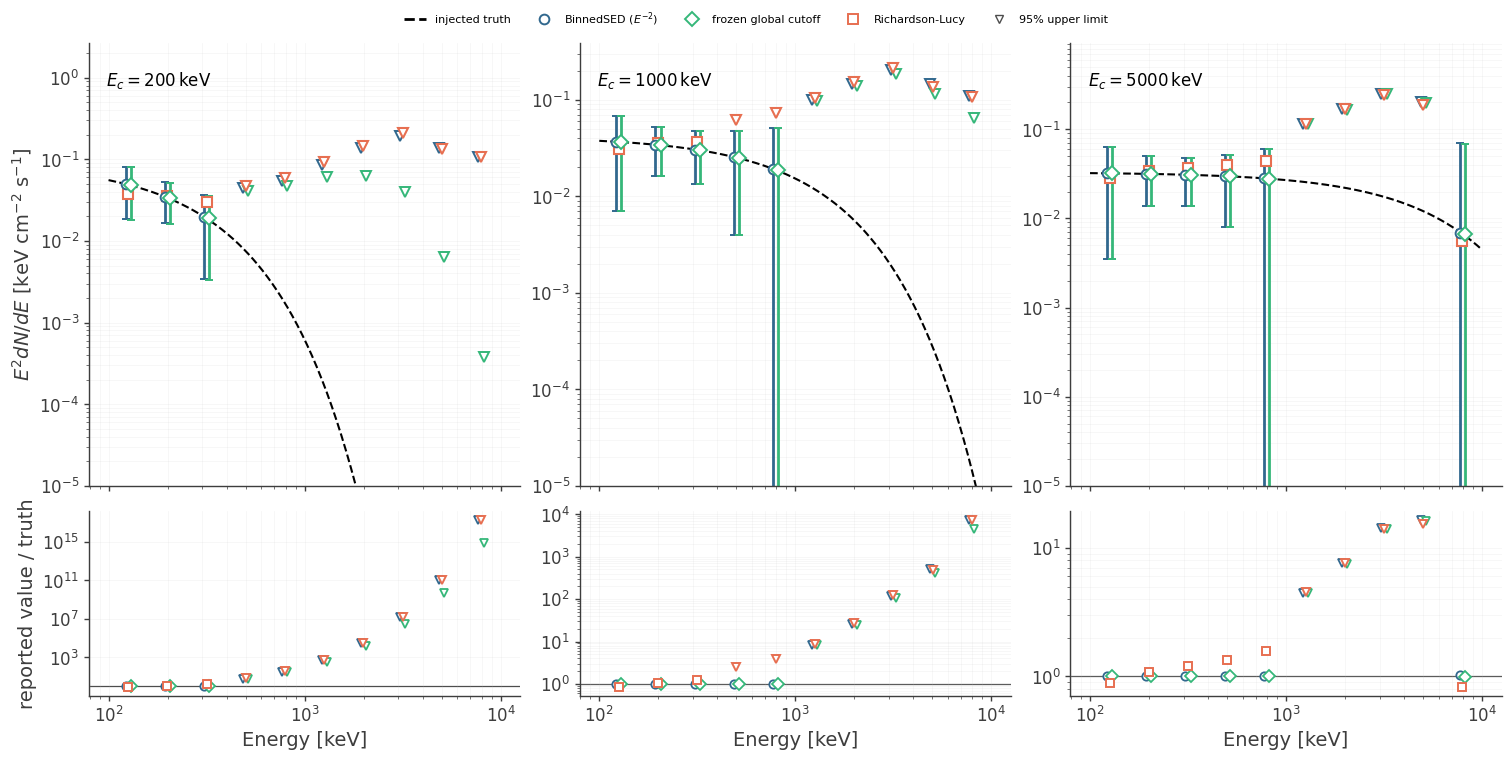

In [9]:
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator

METHOD_STYLE = {
    "simultaneous BinnedSED": {"color": "#31688e", "marker": "o", "offset": 0.97},
    "simultaneous frozen global shape": {"color": "#35b779", "marker": "D", "offset": 1.03},
    "Richardson-Lucy": {"color": "#e76f51", "marker": "s", "offset": 1.00},
}
METHOD_LABEL = {
    "simultaneous BinnedSED": r"BinnedSED ($E^{-2}$)",
    "simultaneous frozen global shape": "frozen global cutoff",
    "Richardson-Lucy": "Richardson-Lucy",
}

fig, axes = plt.subplots(
    2, 3, figsize=(15, 7.5), sharex="col",
    gridspec_kw={"height_ratios": [3.0, 1.25]}, constrained_layout=True,
)
for column, cutoff_keV in enumerate(CUTOFF_ENERGIES_KEV):
    ax_sed, ax_res = axes[:, column]
    energy_grid = np.geomspace(
        comparison_info["energy_edges_keV"][0],
        comparison_info["energy_edges_keV"][-1],
        400,
    )
    truth_grid = _cutoff_truth(cutoff_keV, energy_grid)
    ax_sed.plot(energy_grid, energy_grid**2 * truth_grid, "k--", lw=1.5)

    for method, style in METHOD_STYLE.items():
        subset = sed_comparison[
            (sed_comparison["injected_cutoff_keV"] == cutoff_keV)
            & (sed_comparison["method"] == method)
        ].sort_values("bin")
        energy = subset["energy_keV"].to_numpy()
        x = style["offset"] * energy
        flux = subset["flux"].to_numpy()
        truth = _cutoff_truth(cutoff_keV, energy)

        if method == "Richardson-Lucy":
            is_ul = subset["is_ul"].to_numpy(dtype=bool)
            detected = ~is_ul
            if detected.any():
                ax_sed.plot(
                    x[detected], energy[detected] ** 2 * flux[detected],
                    linestyle="none", marker=style["marker"], ms=7,
                    mfc="white", mec=style["color"], mew=1.5,
                )
                ax_res.plot(
                    x[detected], flux[detected] / truth[detected],
                    linestyle="none", marker=style["marker"], ms=6,
                    mfc="white", mec=style["color"], mew=1.4,
                )
            if is_ul.any():
                ul = subset["ul95"].to_numpy()[is_ul]
                ax_sed.plot(
                    x[is_ul], energy[is_ul] ** 2 * ul, linestyle="none",
                    marker="v", ms=7, mfc="white",
                    mec=style["color"], mew=1.5,
                )
                ax_res.plot(
                    x[is_ul], ul / truth[is_ul], linestyle="none",
                    marker="v", ms=6, mfc="white",
                    mec=style["color"], mew=1.4,
                )
            continue

        is_ul = subset["is_ul"].fillna(False).to_numpy(dtype=bool)
        detected = ~is_ul
        if detected.any():
            y = energy[detected] ** 2 * flux[detected]
            yerr = np.vstack((
                energy[detected] ** 2
                * (flux[detected] - subset["flux_low"].to_numpy()[detected]),
                energy[detected] ** 2
                * (subset["flux_high"].to_numpy()[detected] - flux[detected]),
            ))
            ax_sed.errorbar(
                x[detected], y, yerr=yerr, fmt=style["marker"], ms=7,
                mfc="white", mec=style["color"], mew=1.4,
                ecolor=style["color"], capsize=3, linestyle="none",
            )
            ax_res.plot(
                x[detected], flux[detected] / truth[detected],
                linestyle="none", marker=style["marker"], ms=6,
                mfc="white", mec=style["color"], mew=1.3,
            )
        if is_ul.any():
            ul = subset["ul95"].to_numpy()[is_ul]
            ax_sed.plot(
                x[is_ul], energy[is_ul] ** 2 * ul, linestyle="none", marker="v",
                ms=7, mfc="white", mec=style["color"], mew=1.4,
            )
            ax_res.plot(
                x[is_ul], ul / truth[is_ul],
                linestyle="none", marker="v", ms=6, mfc="white",
                mec=style["color"], mew=1.3,
            )

    ax_sed.text(0.04, 0.94, rf"$E_c={cutoff_keV:g}\,\mathrm{{keV}}$", transform=ax_sed.transAxes, va="top")
    ax_sed.set(xscale="log", yscale="log")
    ax_sed.set_ylim(bottom=1.0e-5)
    ax_res.set_xscale("log")
    ax_res.set_yscale("log")
    ax_res.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax_res.axhline(1.0, color="0.3", lw=0.9, zorder=0)
    ax_res.set_xlabel("Energy [keV]")
    for axis in (ax_sed, ax_res):
        axis.grid(alpha=0.18, which="both")

axes[0, 0].set_ylabel(r"$E^2dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
axes[1, 0].set_ylabel("reported value / truth")
legend_handles = [
    Line2D([], [], color="k", ls="--", label="injected truth"),
    *[
        Line2D([], [], color=style["color"], marker=style["marker"], ls="none",
               mfc="white", mew=1.4, ms=7, label=METHOD_LABEL[method])
        for method, style in METHOD_STYLE.items()
    ],
    Line2D([], [], color="0.3", marker="v", ls="none", mfc="white", label="95% upper limit"),
]
fig.legend(handles=legend_handles, loc="outside upper center", ncol=5, frameon=False)
plt.show()
